nohup python pred_snap.py --model mistral-7B-instruct-v0.2 --compress_args_path ablation_c4096_w64_b32_k7_maxpool.json > 20251210c4096w64b32.log 2>&1 &
nohup python pred_snap.py --model mistral-7B-instruct-v0.2 --compress_args_path ablation_c4096_w64_b128_k7_maxpool.json > 20251210c4096w64b128.log 2>&1 &
nohup python pred_snap.py --model mistral-7B-instruct-v0.2 --compress_args_path ablation_c4096_w64_b512_k7_maxpool.json > 20251210c4096w64b512.log 2>&1 &
nohup python pred_snap.py --model mistral-7B-instruct-v0.2 --compress_args_path ablation_c2048_w64_b64_k7_maxpool.json > 20251210c2048w64b64.log 2>&1 &



新实验：
nohup python pred_snap.py --model mistral-7B-instruct-v0.2 --compress_args_path ablation_c4096_w32_k7_maxpool.json > 20260420c4096w32.log 2>&1 &
nohup python pred_snap.py --model mistral-7B-instruct-v0.2 --compress_args_path ablation_c2048_w32_k7_maxpool.json > 20260420c2048w32.log 2>&1 &
nohup python pred_snap.py --model mistral-7B-instruct-v0.2 --compress_args_path ablation_c1024_w32_k7_maxpool.json > 20260420c1024w32.log 2>&1 &
nohup python pred_snap.py --model mistral-7B-instruct-v0.2 --compress_args_path ablation_c512_w32_k7_maxpool.json > 20260420c512w32.log 2>&1 &


chmod +x autorun1.sh
nohup ./autorun1.sh > autorun10.nohup.log 2>&1 &

kill -9 xxxxxxx

pkill -f run_seq.sh

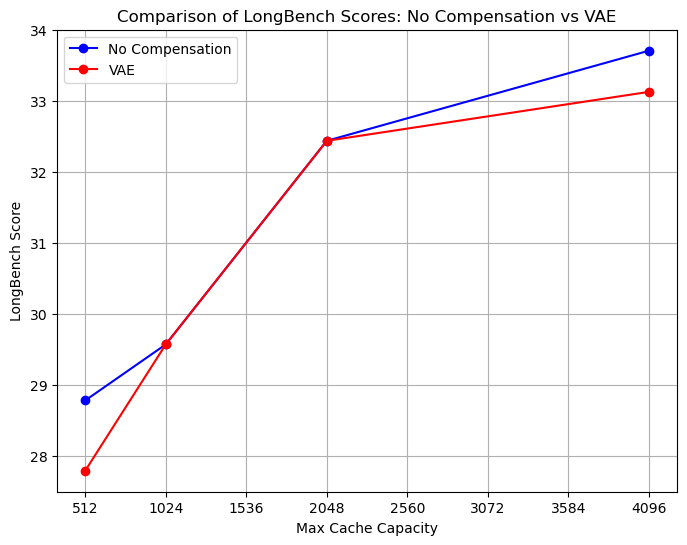

In [4]:
import matplotlib.pyplot as plt
import numpy as np

# Data for No Compensation (control group)
window_size_no_comp = [32, 32, 32, 32]
max_cache_no_comp = [512, 1024, 2048, 4096]
longbench_no_comp = [28.78, 29.57, 32.44, 33.71]

# Data for VAE group
window_size_vae = [32, 32, 32, 32]
max_cache_vae = [512, 1024, 2048, 4096]
longbench_vae = [27.79, 29.57, 32.44, 33.13]

# Create the plot
plt.figure(figsize=(8, 6))

# Plot for No Compensation
plt.plot(max_cache_no_comp, longbench_no_comp, label='No Compensation', marker='o', color='b')

# Plot for VAE
plt.plot(max_cache_vae, longbench_vae, label='VAE', marker='o', color='r')

# Labels and title
plt.xlabel('Max Cache Capacity')
plt.ylabel('LongBench Score')
plt.title('Comparison of LongBench Scores: No Compensation vs VAE')
plt.xticks(np.arange(512, 4600, step=512))
plt.grid(True)

# Show legend
plt.legend()

# Show the plot
plt.show()

先用现在这个版本的VAE测试一下压缩还原能力：
- 即使用latent压缩存储KV、然后在推理时还原KV以计算近似注意力

如果还原能力很好，其实就可以考虑先做成使用latent压缩KV的方案，至于解码峰值这些的后面考虑优化/或者在这上面训练模型然后看预测效果也行，总之不管是预测还是压缩都需要保证压缩还原能力相对好

无补偿性能（对照组）

| 窗口大小 | 最大缓存容量 | 补偿块大小 | 显存消耗  | 推理速度(s) | LongBench得分 |
|------|--------|-------|-------|---------|------------|
| 32   | 512    | 无补偿    | -     | 312     | 28.78      |
| 32   | 1024   | 无补偿    | -     | 312     | 29.57      |
| 32   | 2048   | 无补偿   | 18485 | 311     | 32.44      |
| 32   | 4096   | 无补偿   | 20430 | 336     | 33.71      |

VAE:

| 窗口大小 | 最大缓存容量 | 补偿块大小 | 显存消耗  | 推理速度(s) | LongBench得分 |
|------|--------|-------|-------|---------|------------|
| 32   | 512    | 无补偿    | -     | 312     | 27.79      |
| 32   | 1024   | 无补偿    | -     | 312     | 29.57      |
| 32   | 2048   | 无补偿   | 18485 | 311     | 32.44      |
| 32   | 4096   | 无补偿   | 20430 | 336     | 33.13      |

很好，VAE之后性能几乎不损失
可以考虑先做成使用latent压缩KV的方案（也就是暂时先不考虑拿小模型预测latent），因为VAE很小，latent应该压缩率也相当高（肯定比量化高）
    - KV使用latent存储（也就是用latent替换原有缓存），应该能小很多
    - 问题是latent解码之后和原KV一样大，这个可以参考一下其他压缩方案（主要是低秩、字典这种不能直接在压缩空间中计算注意力的），从应用上来讲可以引入每次仅解压一部分KV、或者看其他方案里面是怎么解决的。这个问题可以之后再考虑，先实现压缩


不对，上面的是没加vae的代码：刚才改latent cache方案的时候发现实验运行的脚本是pred_snap.py，所以只是加载了vae但是没有真正经过vae

重新做了经过vae的代码，答案全是这种：
{"pred": "was was of was was was was was was of was was was was was was was was was of was was was was was was was of of was was was was was was was was was was of of of was was was was was was was was was was was was was was was of was was was was was was was was was was was was was was was was was was was was was was was was was was was was was was was was was was have was was was was was was was was was was was was was was was was was of of of of of of of of was was was was was was was was of of", "answers": ["Ground truth is not established in the paper"], "all_classes": null, "length": 3141}
显然注意力崩溃了，至少说明全用vae是不行的
    - 现在看来显然是vae没练好，解压后的注意力是坏的
    - 但是坏了多少不好说，因为不排除这个结果是因为全部的注意力都过了一次vae导致即使偏一点也会崩溃，但是如果有一定比例的全量注意力就能纠正？
    
试了混合vae和原始kv，虽然很多都报错了，但是能运行的仍然是这种：
{"pred": "the Question Question Question Question Question Question Question Question Question Question Question Question Question Question Question Question Question Question Question Question Question Question Question Question Question Question Question Question Question Question Question Question Question Question Question Question Question Question Question Question Question Question Question Question Question Question Question Question Question Question Question Question Question Question Question Question Question Question Question Question Question Question Question Question Question Question Question Question Question Question Question Question Question Question Question Question Question Question Question Question Question Question Question Question Question Question Question Question Question Question Question Question Question Question Question Question Question Question Question Question Question Question Question Question Question Question Question Question Question Question Question Question Question Question Question Question Question Question Question Question Question Question Question Question Question Question Question", "answers": ["Ground truth is not established in the paper"], "all_classes": null, "length": 3141}

那应该就是vae不行，重新练


新版VAE训练脚本：
每层独立 VAE，默认不跨层共享
K / V 分开建模
按 kv-head 分头压缩，不是整层一锅端
训练默认近似 deterministic AE，KL 极弱
重构损失 = MSE + cosine + relative L2
logvar 被强约束在负区间，避免方差乱飘
保留你原来的：
text-only dataset 支持
双前向 e2e
SDPA 降显存
mu/logvar 统计与 snapshot 保存